### Pre-reqs


The required dataset for this assignment must be downloaded from the following repository:
https://drive.google.com/drive/folders/1-F8gd-kjQ2a-x2EXJYOaLwHhTt4apNBJ

In [118]:
# import libraries

import gdown
from pathlib import Path
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.set_printoptions(suppress=True)

In [119]:
google_url = "https://drive.google.com/drive/folders/1-F8gd-kjQ2a-x2EXJYOaLwHhTt4apNBJ"

download_dir = Path("images/")
download_dir.mkdir(parents=True, exist_ok=True)

# check for download before repeating
expected_folder = download_dir / "images"
required_files = [
    expected_folder / "im1.png",
    expected_folder / "im2.png",
]

# check for folder and files
if not expected_folder.exists() or not all(file_path.exists() for file_path in required_files):

    gdown.download_folder(
        url=google_url,
        output=str(download_dir),
        quiet=False,
        use_cookies=False
    )


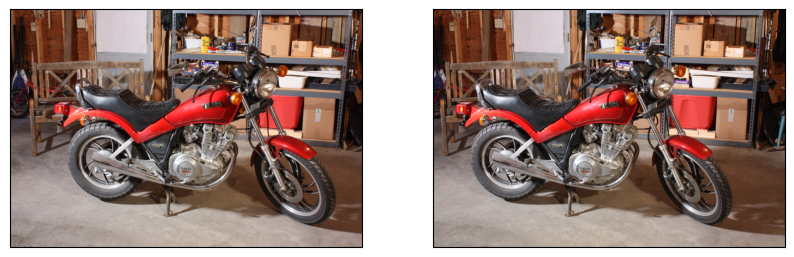

In [120]:
# display the stereo pair
image_dir_candidates = [
    Path("images/images"),
    Path("B31MV_Assignment3_data_(2026)/images"),
    Path("B31MV Assignment3 data (2026)/images"),
]

image_dir = next(
    (
        candidate
        for candidate in image_dir_candidates
        if (candidate / "im1.png").exists() and (candidate / "im2.png").exists()
    ),
    None,
)

if image_dir is None:
    raise FileNotFoundError("Could not locate im1.png and im2.png in the expected dataset folders.")

img1_path = image_dir / "im1.png"
img2_path = image_dir / "im2.png"

img1_bgr = cv.imread(str(img1_path), cv.IMREAD_COLOR)
img2_bgr = cv.imread(str(img2_path), cv.IMREAD_COLOR)

if img1_bgr is None:
    raise FileNotFoundError(f"Could not read image: {img1_path}")
if img2_bgr is None:
    raise FileNotFoundError(f"Could not read image: {img2_path}")

img1 = np.asarray(cv.cvtColor(img1_bgr, cv.COLOR_BGR2RGB))
img2 = np.asarray(cv.cvtColor(img2_bgr, cv.COLOR_BGR2RGB))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

ax[0].imshow(img1)
ax[1].imshow(img2)

plt.show()

In [121]:
# data inputs
candidate_data_roots = [
    Path("B31MV_Assignment3_data_(2026)"),
    Path("B31MV Assignment3 data (2026)"),
    Path("images"),
]

data_root = next(
    (
        root
        for root in candidate_data_roots
        if (root / "intrinsics.npz").exists() and (root / "some_corresp.npz").exists()
    ),
    None,
)

if data_root is None:
    raise FileNotFoundError("Could not locate intrinsics.npz and some_corresp.npz in the expected dataset folders.")

data_intrinsics_path = data_root / "intrinsics.npz"
data_corresp_path = data_root / "some_corresp.npz"

print(f"Using data root: {data_root}")

Using data root: images


# Section 1 : Sparse Reconstruction

## Part 1.1
Implement the eight-point algorithm to estimate the fundamental matrix (F) that relates the two views
- scale pixel coords by 1/M
- solve using singular valve decomposition (SVD)
- enforce the rank2 constraint by zeroing the smallest singular value before un-normalising F=F^{T}F_{norm}T

required output

- computed 3x3 fundamental matrix (F)
- A visualization displaying selected points in Image 1 and their corresponding epipolar
lines in Image 2



In [122]:
# load the matched correspondences
data = np.load(data_corresp_path)
pts1 = data["pts1"].astype(np.float64)
pts2 = data["pts2"].astype(np.float64)

if pts1.shape != pts2.shape or pts1.shape[1] != 2:
    raise ValueError("pts1 and pts2 must both have shape (N, 2)")

if img1 is None or img2 is None:
    raise RuntimeError("Input images must be loaded before computing the fundamental matrix")

M = max(img1.shape[0], img1.shape[1], img2.shape[0], img2.shape[1])

T = np.array([
    [1 / M, 0, 0],
    [0, 1 / M, 0],
    [0, 0, 1],
])

pts1_h = np.column_stack([pts1, np.ones(len(pts1))])
pts2_h = np.column_stack([pts2, np.ones(len(pts2))])

pts1_n = (T @ pts1_h.T).T
pts2_n = (T @ pts2_h.T).T

x1, y1 = pts1_n[:, 0], pts1_n[:, 1]
x2, y2 = pts2_n[:, 0], pts2_n[:, 1]

A = np.column_stack([
    x2 * x1, x2 * y1, x2,
    y2 * x1, y2 * y1, y2,
    x1, y1, np.ones_like(x1),
]).astype(np.float64)

print("pts1 shape:", pts1.shape)
print("pts2 shape:", pts2.shape)
print("A shape:", A.shape)

pts1 shape: (3439, 2)
pts2 shape: (3439, 2)
A shape: (3439, 9)


In [123]:
# solve Af = 0 with SVD
_, _, vt = cv.SVDecomp(A)
F_norm = vt[-1].reshape(3, 3)

# enforce rank-2 on the normalized fundamental matrix
w, u, vt = cv.SVDecomp(F_norm)
w[-1, 0] = 0
F_norm = u @ np.diag(w.flatten()) @ vt

# un-normalize back to pixel coordinates
F = T.T @ F_norm @ T

# scale for easier reading
if not np.isclose(F[-1, -1], 0.0):
    F = F / F[-1, -1]

print("Fundamental matrix F:")
print(F)

Fundamental matrix F:
[[ 0.          0.00000111  0.00041297]
 [-0.0000009  -0.00000007  1.23013634]
 [-0.00125991 -1.23001705  1.        ]]


In [124]:
# extract points based on a limited selection

num_points = 15
indices = np.linspace(0,len(pts1) -1 , num_points, dtype=int)

sample_pts1 = pts1[indices]
sample_pts2 = pts2[indices]

sample_pts1_h = np.column_stack([sample_pts1, np.ones(len(sample_pts1))])
epilines_img2 = (F @ sample_pts1_h.T).T # each row is [a,b,b]

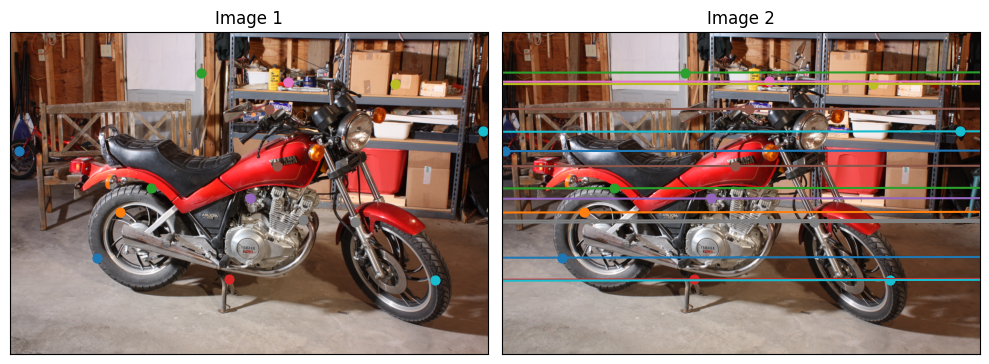

In [125]:
# plot these points

if img1 is None or img2 is None:
    raise RuntimeError("Images must be loaded before visualization")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(img1)
ax[1].imshow(img2)

ax[0].set_title("Image 1")
ax[1].set_title("Image 2")

for a in ax:
    a.set_yticks([])
    a.set_xticks([])

height, width = img2.shape[:2]
colors = plt.get_cmap("tab10")(np.linspace(0, 1, num_points))

for i, color in enumerate(colors):
    x1, y1 = sample_pts1[i]
    x2, y2 = sample_pts2[i]

    a_line, b_line, c_line = epilines_img2[i]

    # draw point in image 1
    ax[0].scatter(x1, y1, color=color, s=40)

    # draw matched point in image 2 for checking
    ax[1].scatter(x2, y2, color=color, s=40)

    if abs(b_line) > 1e-8:
        x_vals = np.array([0, width - 1])
        y_vals = -(a_line * x_vals + c_line) / b_line
        ax[1].plot(x_vals, y_vals, color=color, linewidth=1.5)
    elif abs(a_line) > 1e-8:
        x_val = -c_line / a_line
        ax[1].plot([x_val, x_val], [0, height - 1], color=color, linewidth=1.5)

plt.tight_layout()
plt.show()

## Part 1.2: Epipolar Correspondences

Find matching coordinates in the target image by searching along epipolar lines defined
by F.
- Use the Sum of Squared Differences (SSD) over a 15×15 window to find the match that minimizes the error along the sampled epipolar line l = Fx.

Required Outputs:
- A list or table displaying the coordinates of five reference points in Image 1 and their corresponding estimated matches in Image 2.

In [126]:
# pre-process by turning images in grayscale
img1_gray = cv.cvtColor(img1, cv.COLOR_RGB2GRAY).astype(np.float64) # type: ignore
img2_gray = cv.cvtColor(img2, cv.COLOR_RGB2GRAY).astype(np.float64) # type: ignore

window_size = 15
half_window = window_size // 2

In [127]:
# function for testing extract
def extract_patch(image, x, y, half_window):
    x = int(round(x))
    y = int(round(y))
    return image[
        y - half_window : y + half_window + 1,
        x - half_window : x + half_window + 1,
    ]

def patch_ssd(patch1, patch2):
    return np.sum((patch1 - patch2) ** 2)

def find_epipolar_match(img1_gray, img2_gray, F, point1, half_window=7):
    x1, y1 = point1
    h2, w2 = img2_gray.shape

    # reference patch from image 1
    if (
        x1 < half_window or x1 >= img1_gray.shape[1] - half_window or
        y1 < half_window or y1 >= img1_gray.shape[0] - half_window
    ):
        raise ValueError("Reference point too close to the boundary in image 1")

    ref_patch = extract_patch(img1_gray, x1, y1, half_window)

    # epipolar line in image 2
    point1_h = np.array([x1, y1, 1.0])
    a, b, c = F @ point1_h

    best_point = None
    best_error = np.inf

    if abs(b) > abs(a):
        for x in range(half_window, w2 - half_window):
            y = -(a * x + c) / b
            if y < half_window or y >= h2 - half_window:
                continue

            candidate_patch = extract_patch(img2_gray, x, y, half_window)
            error = patch_ssd(ref_patch, candidate_patch)

            if error < best_error:
                best_error = error
                best_point = (x, int(round(y)))
    else:
        for y in range(half_window, h2 - half_window):
            x = -(b * y + c) / a
            if x < half_window or x >= w2 - half_window:
                continue

            candidate_patch = extract_patch(img2_gray, x, y, half_window)
            error = patch_ssd(ref_patch, candidate_patch)

            if error < best_error:
                best_error = error
                best_point = (int(round(x)), y)

    return best_point, best_error


In [128]:
# test the func on a single point
test_point = tuple(sample_pts1[0])
matched_point, error = find_epipolar_match(img1_gray, img2_gray, F, test_point, half_window)

print(f"Test point in image 1: {test_point}")
print(f"Matched point in image 2: {matched_point}")
print(f"SSD error: {error}")

Test point in image 1: (np.float64(55.528594970703125), np.float64(740.7119140625))
Matched point in image 2: (14, 740)
SSD error: 3226.0


In [129]:
# now do on 5
reference_indices = np.linspace(0,len(pts1) -1, 5, dtype=int)

results = []

for idx in reference_indices:
    point1 = tuple(pts1[idx])
    match2, error = find_epipolar_match(img1_gray, img2_gray, F, point1, half_window)
    results.append((point1, match2, error))

for i, (point1, match2, error) in enumerate(results, start=1):
    print(f"{i}. Point in image 1: {point1}, Matched point in image 2: {match2}, SSD error: {error}")

1. Point in image 1: (np.float64(55.528594970703125), np.float64(740.7119140625)), Matched point in image 2: (14, 740), SSD error: 3226.0
2. Point in image 1: (np.float64(1035.0772705078125), np.float64(1313.0745849609375)), Matched point in image 2: (846, 1313), SSD error: 10568.0
3. Point in image 1: (np.float64(1606.6195068359375), np.float64(478.0445556640625)), Matched point in image 2: (1533, 478), SSD error: 14932.0
4. Point in image 1: (np.float64(1947.13232421875), np.float64(283.013671875)), Matched point in image 2: (1876, 283), SSD error: 18436.0
5. Point in image 1: (np.float64(2934.146484375), np.float64(616.3624267578125)), Matched point in image 2: (2839, 617), SSD error: 12571.0


In [130]:
# display as a table
rows = []
for point1, match2, error in results:
        rows.append({
                "img1_x": point1[0],
                "img2_x": match2[0],
                "img1_y": point1[1],
                "img2_y": match2[1],
                "ssd": error,
        })

pd.DataFrame(rows)        

,img1_x,img2_x,img1_y,img2_y,ssd
0,55.528595,14,740.711914,740,3226.0
1,1035.077271,846,1313.074585,1313,10568.0
2,1606.619507,1533,478.044556,478,14932.0
3,1947.132324,1876,283.013672,283,18436.0
4,2934.146484,2839,616.362427,617,12571.0


## Part 1.3 Essential Matrix
Convert fundamental matrix to the essential matrix using camera calibration data 
- calculate the matrix using the calibrated geometry equation E = K_2^T F K_1

Required outputs
- numerical values of the 3x3 essential matrix E

In [131]:
# calibration data is stored in intrinsics.npz
intrinsics_data = np.load(data_intrinsics_path)
K1 = intrinsics_data["K1"]
K2 = intrinsics_data["K2"]
print(f"K1: {K1}");print(f"K2: {K2}")

E = K2.T @ F @ K1
print("Essential matrix E:")
print(E)

K1: [[3979.911    0.    1244.772]
 [   0.    3979.911 1019.507]
 [   0.       0.       1.   ]]
K2: [[3979.911    0.    1369.115]
 [   0.    3979.911 1019.507]
 [   0.       0.       1.   ]]
Essential matrix E:
[[    0.01320554    17.57988815     6.15103907]
 [  -14.27269502    -1.16108987  4891.07174026]
 [   -8.66592238 -4889.60824123     0.44961116]]


## Part 1.4 Triangulation
Reconstruct 3D points from 2D correspondences using the linear triangulation method
- utilise SVD to solve homogenous system for 3D coords

output
- calculated mean re-projection error (must be less than 2px)
- verify that triangulated points satisfy the chirality constant (Z>0)


In [132]:
# load the remaining data

R1 = intrinsics_data["R1"]
R2 = intrinsics_data["R2"]
t1 = intrinsics_data["t1"]
t2 = intrinsics_data["t2"]

# collate related points
P1 = K1 @ np.hstack([R1, t1])
P2 = K2 @ np.hstack([R2, t2])

# verify points
print(f"P1 shape: {P1.shape}, P2 shape: {P2.shape}")

P1 shape: (3, 4), P2 shape: (3, 4)


In [133]:
# triangulate points

# function
def triangulate_point(P1, P2, point1, point2):
    x1, y1 = point1
    x2, y2 = point2

    A = np.vstack([
        x1 * P1[2] - P1[0],
        y1 * P1[2] - P1[1],
        x2 * P2[2] - P2[0],
        y2 * P2[2] - P2[1],
    ])

    _, _, vt = np.linalg.svd(A)
    X_h = vt[-1]
    X = X_h[:3] / X_h[3]
    return X

# find 3d points
points_3D = np.array([
    triangulate_point(P1, P2, pts1[i], pts2[i])
    for i in range(len(pts1))
])

print(f"Triangulated 3D points shape: {points_3D.shape}")
print(points_3D[:5])

Triangulated 3D points shape: (3439, 3)
[[-1383.56561795  -325.02590969  4630.22774349]
 [-1387.77054882  -195.38590888  4657.98118385]
 [-1387.77054882  -195.38590888  4657.98118385]
 [-1345.21358302  -358.9019112   4581.78401233]
 [-1326.02556368  -347.86806563  4554.94302021]]


In [134]:
# find the mean reprojection error and verify chirality constraint

# project the points into 3d
def project_points(P, points_3D):
    points_3D_h = np.column_stack([points_3D, np.ones(len(points_3D))])
    projected_h = (P @ points_3D_h.T).T
    projected = projected_h[:, :2] / projected_h[:, 2:]
    return projected

# do projection
projected_1 = project_points(P1, points_3D)
projected_2 = project_points(P2, points_3D)

error1 = np.linalg.norm(projected_1 - pts1, axis=1)
error2 = np.linalg.norm(projected_2 - pts2, axis=1)
mean_proj_error = (np.mean(error1) + np.mean(error2)) / 2

print(f"Mean reprojection error: {mean_proj_error:.4f}")

# chirality (lies infront of both cameras)
points_cam1 = (R1 @ points_3D.T + t1).T
points_cam2 = (R2 @ points_3D.T + t2).T

chirality_mask = (points_cam1[:, 2] > 0) & (points_cam2[:, 2] > 0)

print(f"Num of points satisfying chirality: {np.sum(chirality_mask)} out of {len(points_3D)}")
print(f"All points satisfy chirality: {np.all(chirality_mask)}")

Mean reprojection error: 0.1700
Num of points satisfying chirality: 3439 out of 3439
All points satisfy chirality: True


## Part 1.5 Full 3D sparse model
Integrate all previous parts to create a complete 3d sparse model using the provided correspondences 
- project validated correspondences into 3D space
- visualise resulting point cloud using standard coord orientations

output
- 3D scatter plot of the reconstructed scene

In [135]:
# build validated 3D space 
point_errors = 0.5 * (error1 + error2)
valid_mask = chirality_mask & (point_errors < 2.0)

valid_points_3D = points_3D[valid_mask]
valid_point_errors = point_errors[valid_mask]

print(f"Valid 3D points: {len(valid_points_3D) / len(points_3D)}")
print(f"Mean error of valid points: {np.mean(valid_point_errors):.4f} px")

Valid 3D points: 1.0
Mean error of valid points: 0.1700 px


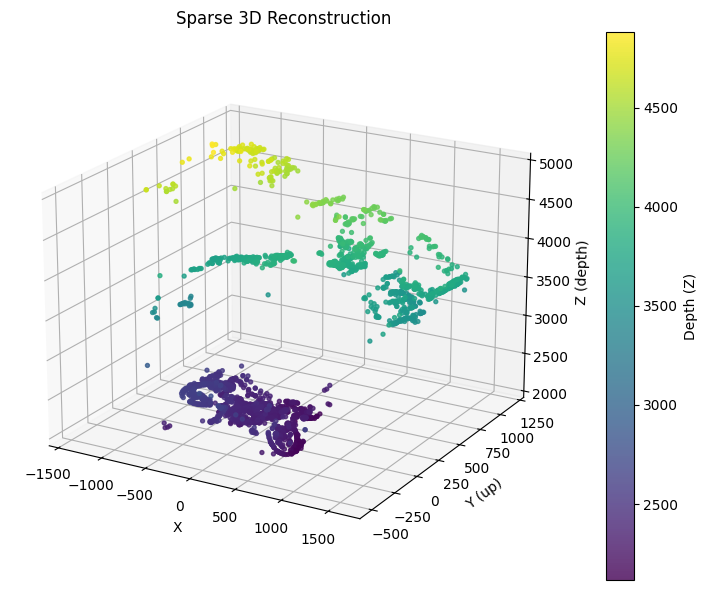

In [136]:
# plot the valid 3D points

fig = plt.figure(figsize=(10,6))
ax3d = fig.add_subplot(111, projection='3d')

# using -Y 
x_plot = valid_points_3D[:, 0]
y_plot = -valid_points_3D[:, 1]
z_plot = valid_points_3D[:, 2]

scatter = ax3d.scatter(
    x_plot, y_plot, z_plot, # type: ignore
    c=z_plot, 
    cmap="viridis",
    s=8,
    alpha=0.8,
)

ax3d.set_title("Sparse 3D Reconstruction")
ax3d.set_xlabel("X")
ax3d.set_ylabel("Y (up)")
ax3d.set_zlabel("Z (depth)")

fig.colorbar(scatter, ax=ax3d, label="Depth (Z)")
ax3d.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.show()

In [137]:
# trying interactve plotting 
import plotly.express as px

plot_df = pd.DataFrame({
    "X": valid_points_3D[:, 0],
    "Y": -valid_points_3D[:, 1],
    "Z": valid_points_3D[:, 2],
    "depth": valid_points_3D[:, 2],
})

fig = px.scatter_3d(
    plot_df,
    x="X",
    y="Y",
    z="Z",
    color="depth",
    color_continuous_scale="viridis",
    opacity=0.8,
)

fig.update_traces(marker=dict(size=2))
fig.update_layout(title="Interactive Sparse 3D Reconstruction")
fig.show()

# Section 2: Dense Reconstruction 
## Part 2.1 Image rectification
Wrap the stereo images so that all epipolar lines become horizontal and colinear 
- compute rectification matrices M_1 , M_2 using the provided camera extrinsics to reduce the correspondence search to a 1D horizontal operation

outputs
- side-by-side visualisation of the rectified left and right images

In [138]:
# compute rectification transforms

# find 1d size
image_size = (img1.shape[1], img1.shape[0]) # type: ignore

# relative poses
R = R2 @ R1.T
t = t2 - R @ t1

# 
dist1 = np.zeros(5)
dist2 = np.zeros(5)

R_rect1, R_rect2, P_rect1, P_rect2, Q, _, _ = cv.stereoRectify(
    K1,
    dist1,
    K2,
    dist2,
    image_size,
    R,
    t,
    flags=cv.CALIB_ZERO_DISPARITY,
    alpha=0
)

print("Rectification matrix M1:")
print(R_rect1)
print("Rectification matrix M2:")
print(R_rect2)

Rectification matrix M1:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Rectification matrix M2:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [139]:
# build the remap functions and rectify the images

map1_x, map1_y = cv.initUndistortRectifyMap(
    K1, dist1, R_rect1, P_rect1, image_size, cv.CV_32FC1
)

map2_x, map2_y = cv.initUndistortRectifyMap(
    K2, dist2, R_rect2, P_rect2, image_size, cv.CV_32FC1
)

# do rect
img1_rect = cv.remap(img1, map1_x, map1_y, interpolation=cv.INTER_LINEAR) # type: ignore
img2_rect = cv.remap(img2, map2_x, map2_y, interpolation=cv.INTER_LINEAR) # type: ignore

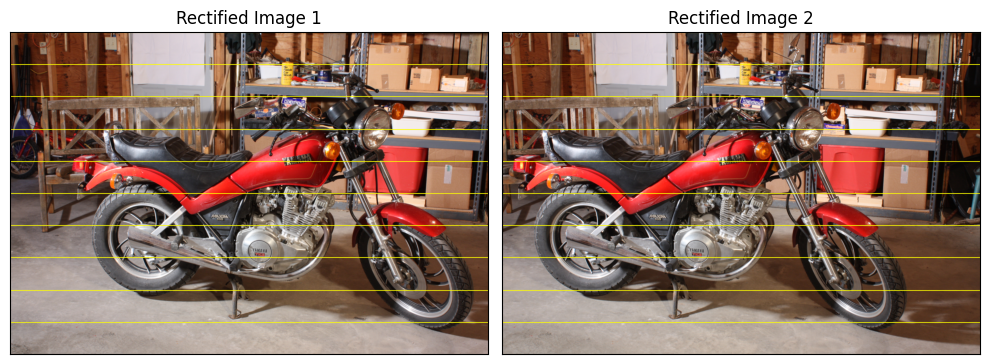

In [140]:
# visualise rectified images side-by-side

fig, ax_remap = plt.subplots(1, 2, figsize=(10, 5))

ax_remap[0].imshow(img1_rect)
ax_remap[1].imshow(img2_rect)

ax_remap[0].set_title("Rectified Image 1")
ax_remap[1].set_title("Rectified Image 2")

for ax in ax_remap:
    ax.set_xticks([])
    ax.set_yticks([])
    for y in range(0, img1_rect.shape[0], 200):
        ax.axhline(y, color='yellow', linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.show()


## Dense Disparity Map
Generate a high-res disparity map using a semi-global-matching (SGBM) approach 
- implement the disparity estimation using global smoothness constraints and multi-way matching mode to optimise depth accuracy across the search range

output
- colour mapped vis of the dense disparity map (dispM) using a colour bar to indicate pixel shift

In [141]:
# build a disparity map using OpenCV SGBM without any filling
img1_rect_gray = cv.cvtColor(img1_rect, cv.COLOR_RGB2GRAY)
img2_rect_gray = cv.cvtColor(img2_rect, cv.COLOR_RGB2GRAY)

clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img1_rect_gray = clahe.apply(img1_rect_gray)
img2_rect_gray = clahe.apply(img2_rect_gray)

img1_rect_gray = cv.GaussianBlur(img1_rect_gray, (5, 5), 0)
img2_rect_gray = cv.GaussianBlur(img2_rect_gray, (5, 5), 0)

window_size = 5
min_disp = 0
num_disp = 16 * 20

SGBM = cv.StereoSGBM_create( # type: ignore
    minDisparity=min_disp,
    numDisparities=num_disp,
    blockSize=window_size,
    P1=8 * window_size ** 2,
    P2=32 * window_size ** 2,
    disp12MaxDiff=-1,
    uniquenessRatio=1,
    speckleWindowSize=0,
    speckleRange=1,
    preFilterCap=63,
    mode=cv.STEREO_SGBM_MODE_SGBM_3WAY,
)

disp_raw = SGBM.compute(img1_rect_gray, img2_rect_gray)
disp_left = disp_raw.astype(np.float32) / 16.0

invalid = ~np.isfinite(disp_left) | (disp_left <= min_disp)
disp_valid = disp_left.copy()
disp_valid[invalid] = np.nan
disparity = disp_valid.copy()

if np.all(invalid):
    raise ValueError("SGBM returned no valid disparities.")

invalid_ratio = 100.0 * np.mean(invalid)
print(f"Invalid ratio: {invalid_ratio:.2f}%")
print(f"Raw disparity range: {np.nanmin(disparity):.2f} to {np.nanmax(disparity):.2f}")

Invalid ratio: 29.61%
Raw disparity range: 0.56 to 319.00


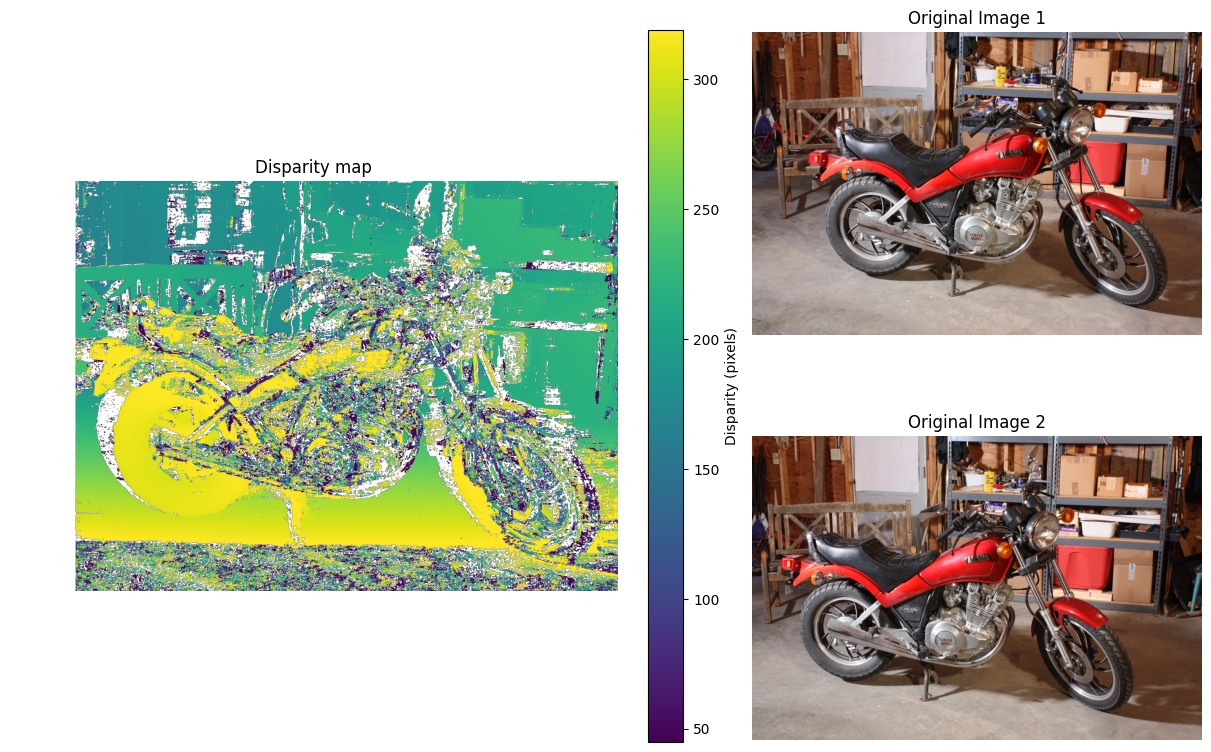

In [142]:
# visualise the disparity map with the original images stacked on the right
vmin = np.nanpercentile(disparity, 5)
vmax = np.nanpercentile(disparity, 95)

fig = plt.figure(figsize=(12, 8), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=[1.35, 1.0])

ax_disparity = fig.add_subplot(gs[:, 0])
ax_img1 = fig.add_subplot(gs[0, 1])
ax_img2 = fig.add_subplot(gs[1, 1])

im = ax_disparity.imshow(disparity, cmap='viridis', vmin=vmin, vmax=vmax)
ax_disparity.set_title("Disparity map")
ax_disparity.axis('off')

ax_img1.imshow(img1)
ax_img1.set_title("Original Image 1")
ax_img1.axis('off')

ax_img2.imshow(img2)
ax_img2.set_title("Original Image 2")
ax_img2.axis('off')

fig.colorbar(im, ax=ax_disparity, shrink=0.9, label='Disparity (pixels)')
plt.show()

## Part 2.3 Depth map generation 
Convert the pixel-based disparity map into a depth map using the provided stereo extrinsics.
- use the formula Z(x,y) = \frac{b*f}{\dispM(x,y)}
- report depth in the same units as the provided camera translations in `intrinsics.npz`

outputs
- vis of the dense depth map using a perceptually uniform colour map
- baseline (b) and scaled focal length (f) used in the calc


In [143]:
# already some relevant vars: P_rect1, P_rect2, Q, disparity

# rectified focal length in pixels and stereo baseline from the provided extrinsics
f = float(P_rect1[0, 0])
b = float(abs(P_rect2[0, 3] / P_rect2[0, 0]))

# compute depth from disparity in the same units as the provided camera translations
valid_depth_mask = np.isfinite(disparity) & (disparity > 0)
depth = np.full_like(disparity, np.nan, dtype=np.float32)
depth[valid_depth_mask] = (b * f) / disparity[valid_depth_mask]

if not np.any(valid_depth_mask):
    raise ValueError("No valid positive disparities available for depth computation.")

print(f"Scaled focal length (f): {f:.2f} pixels")
print(f"Baseline (b): {b:.6f} in the provided translation units")
print(f"Valid depth ratio: {100.0 * np.mean(valid_depth_mask):.2f}%")
print(f"Depth range: {np.nanmin(depth):.2f} to {np.nanmax(depth):.2f} in the provided translation units")

Scaled focal length (f): 4178.69 pixels
Baseline (b): 193.001000 in the provided translation units
Valid depth ratio: 70.39%
Depth range: 2528.19 to 1433763.12 in the provided translation units


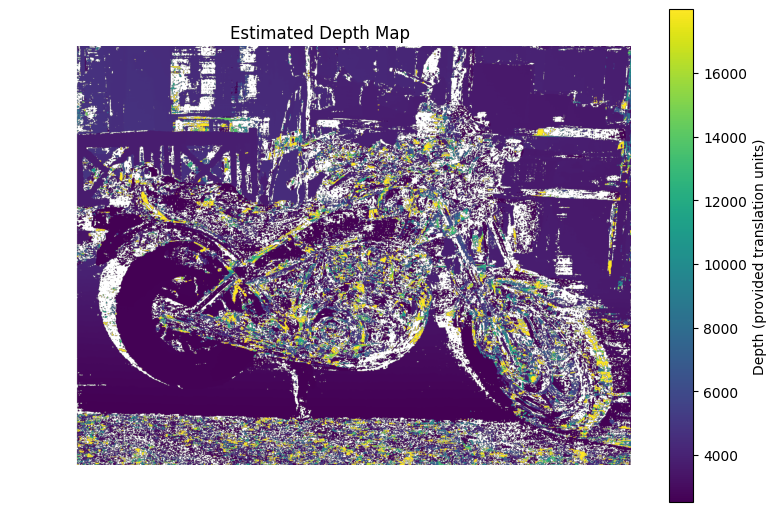

In [144]:
# now we vis the depth map

depth_vis = depth.copy()

vmin = float(np.nanpercentile(depth_vis, 5))
vmax = float(np.nanpercentile(depth_vis, 95))

fig, ax_depth = plt.subplots(figsize=(10, 8))
im_depth = ax_depth.imshow(depth_vis, cmap='viridis', vmin=vmin, vmax=vmax)

ax_depth.set_title("Estimated Depth Map")
ax_depth.axis('off')

fig.colorbar(im_depth, ax=ax_depth, shrink=0.8, label='Depth (provided translation units)')
plt.show()